In [1]:
import os
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from torch_geometric.loader import NeighborLoader
from torch_geometric.utils import to_undirected
from torch_geometric.utils.convert import from_networkx
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR

from dotenv import load_dotenv

warnings.filterwarnings("ignore")

In [2]:
# current dir
notebooks_dir = Path().resolve()
# repo root
repo_root = notebooks_dir.parent.parent
# src
src_path = repo_root / "src"
# bsard data path
bsard_data_path = repo_root / "data" / "BSARD_dataset"

# insert src in sys.path for importing modules
sys.path.insert(0, str(src_path))


In [4]:
###############
# PIPELINE CONFIG
###############

# Load GraphSAGE config file
config_file_path = os.path.join(
    repo_root, "config", "graphsage_config.yaml"
    )

with open(config_file_path, "r") as f:
    config = yaml.safe_load(f)


# Preprocessing parameters
keyterm_mincount = config['preprocessing_params']['keyterm_mincount']
uniqueact_mincount = config['preprocessing_params']['uniqueact_mincount']
n_similarity_edges = config['preprocessing_params']['n_similarity_edges']
print(f"Keyterm mincount: {keyterm_mincount}")
print(f"Unique act mincount: {uniqueact_mincount}")
print(f"Number of sem. similarity edges: {n_similarity_edges}")

# Model 
model_name = config['model']['model_name']
model_channels = config['model']['model_channels']
print(f"Model name: {model_name}")
print(f"Model channels: {model_channels}")

# Loader parameters
num_neighbors = config['loader_params']['num_neighbors']
batch_size = config['loader_params']['batch_size']
shuffle = config['loader_params']['shuffle']
print(f"Number of neighbors by hop: {num_neighbors}")
print(f"Batch size: {batch_size}")
print(f"Shuffle: {shuffle}")

# Input data
graph_file_name = config['input_data']['graph_file_name']
print(f"Input graph file name: {graph_file_name}")

# Optimizer parameters
learning_rate = config['optimizer_params']['learning_rate']
print(f"Learning rate: {learning_rate}")

# Training parameters
num_epochs = config['training_params']['num_epochs']
print(f"Number of training epochs: {num_epochs}")

# Bundle tag
bundle_tag = config["bundle_tag"]
print(f"Bundle tag: {bundle_tag}")

Keyterm mincount: 6
Unique act mincount: 4
Number of sem. similarity edges: 2
Model name: GraphSAGE_V3_max
Model channels: [1024, 1024]
Number of neighbors by hop: [5]
Batch size: 256
Shuffle: True
Input graph file name: BSARD_dataset/intermediate/G_pretraining.pkl
Learning rate: 0.0005
Number of training epochs: 5
Bundle tag: POST_TRIPLE_POSITIVE


In [5]:
###############
# CUDA STATUS
###############

print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")
print("CUDA Device Count:", torch.cuda.device_count())

CUDA Available: True
GPU Name: NVIDIA L40S
CUDA Device Count: 1


In [5]:
###############
# BASE DOCUMENT GRAPH BUILDING
###############

from BSARD.doc_graph_building import build_document_graph

# Load inputs
bsard_corpus_path = 'inputs/bsard_corpus.csv'
bsard_corpus = pd.read_csv(os.path.join(bsard_data_path, bsard_corpus_path))

# Execute main
G_base, bsard_corpus_lean = build_document_graph(bsard_corpus)

# Save outputs
with open(os.path.join(bsard_data_path, 'intermediate', "G_base.pkl"), 'wb') as f:
    pickle.dump(G_base, f)

bsard_corpus_lean.to_csv(os.path.join(bsard_data_path, 'intermediate', "bsard_corpus_processed.csv"))

In [6]:
###############
# HYBRID GRAPH BUILDING
###############

from BSARD.hybrid_graph_building import build_hybrid_graph

# Load inputs
G_base_path = os.path.join(bsard_data_path, 'intermediate', 'G_base.pkl')
with open(G_base_path, 'rb') as f:
    G_base = pickle.load(f)

keyterms_dict_path = os.path.join(bsard_data_path, 'inputs', 'keyterms_dict.pkl')
with open(keyterms_dict_path, 'rb') as f:
    keyterms_dict = pickle.load(f)

# Execute main
G_hybrid = build_hybrid_graph(G_base, keyterms_dict, keyterm_mincount=keyterm_mincount, unique_act_mincount=uniqueact_mincount)

# Save outputs
with open(os.path.join(bsard_data_path, 'intermediate', "G_hybrid.pkl"), 'wb') as f:
    pickle.dump(G_hybrid, f)

In [7]:
###############
# SEMANTIC EMBEDDING GENERATON
###############

from BSARD.semantic_embedding_genration import assign_semantinc_node_embeddings

# Define key values
load_dotenv(os.path.join(repo_root, '.env'))
NGROK_URL = os.getenv("NGROK_URL")
API_TOKEN = os.getenv("API_KEY")

# Load inputs
with open(os.path.join(bsard_data_path, "intermediate", "G_hybrid.pkl"), 'rb') as f:
    G_hybrid = pickle.load(f)

# Execute main
G_semantic = assign_semantinc_node_embeddings(G_hybrid, url=NGROK_URL, api_token=API_TOKEN)

# Ensure all nodes have an attribute "embedding"
assert all("embedding" in data for _, data in G_semantic.nodes(data=True)), "Some nodes lack an embedding!"

# Save outputs
with open(os.path.join(bsard_data_path, 'intermediate/G_semantic.pkl'), 'wb') as f:
    pickle.dump(G_semantic, f)

Generating Central Node embedding... : 100%|██████████| 1/1 [00:00<00:00, 902.39it/s]


In [ ]:
###############
# SEMANTIC EDGES
###############

from BSARD.semantic_edges import add_semantic_edges

# Load inputs
with open(os.path.join(bsard_data_path, "intermediate", "G_semantic.pkl"), 'rb') as f:
    G_semantic = pickle.load(f)

# Execute main
G_pretraining = add_semantic_edges(G_semantic, n=n_similarity_edges)

# Save outputs
with open(os.path.join(bsard_data_path, 'intermediate/G_pretraining.pkl'), 'wb') as f:
    pickle.dump(G_pretraining, f)

Number of article nodes: 22625
[-0.006365415, 0.011672591, -0.030560708, -0.0014849487, -0.046756506, -0.0072449017, 0.06577218, 0.02317325, -0.0067556025, 0.014162728, -0.009448052, -0.0102586895, -0.02208003, 0.012046797, 0.019954184, -0.01705935, 0.039248336, 0.029798634, -0.01957287, -0.028551828, -0.04128564, -0.06194378, -0.021671802, 0.039595228, 0.004332404, -0.02076099, 0.03518242, 0.021258134, 0.031787895, -0.00016106453, 0.03703076, -0.013665759, 0.052258775, -0.060145035, -0.02060499, -0.07419223, 7.3149975e-05, -0.012348542, -0.047265094, 0.06262648, 0.04199956, -0.047716685, 0.020279674, -0.02327837, 0.018944105, -0.038939968, -0.021837413, -0.022231646, -0.025781002, 0.029465105, 0.028990204, 0.017913545, 0.051208925, -0.03904337, -0.060339358, 0.0031292744, -0.01580353, 0.0034206137, -0.0056894477, -0.0057556103, -0.020273987, -0.007487863, -0.015228638, -0.010032098, 0.018107435, -0.02227995, 0.013702314, 0.022425594, -0.025577515, -0.03789098, 0.024082085, -0.01233202

Training epochs: 100%|██████████| 5/5 [03:34<00:00, 42.91s/it, avg_loss=1.2614, mean_norm=0.9814, std_norm=0.1956]


/home/diomedea/Desktop/Repos/GraphRAG-internship-Diego/data/retrieval_bundles/POST_TRIPLE_POSITIVE_1hop_5epochs_1024-1024


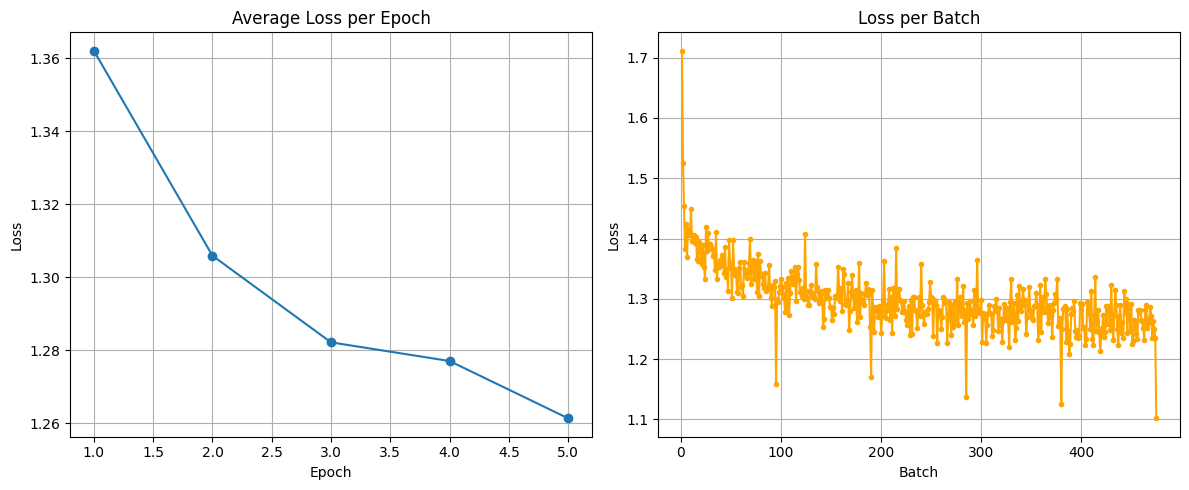

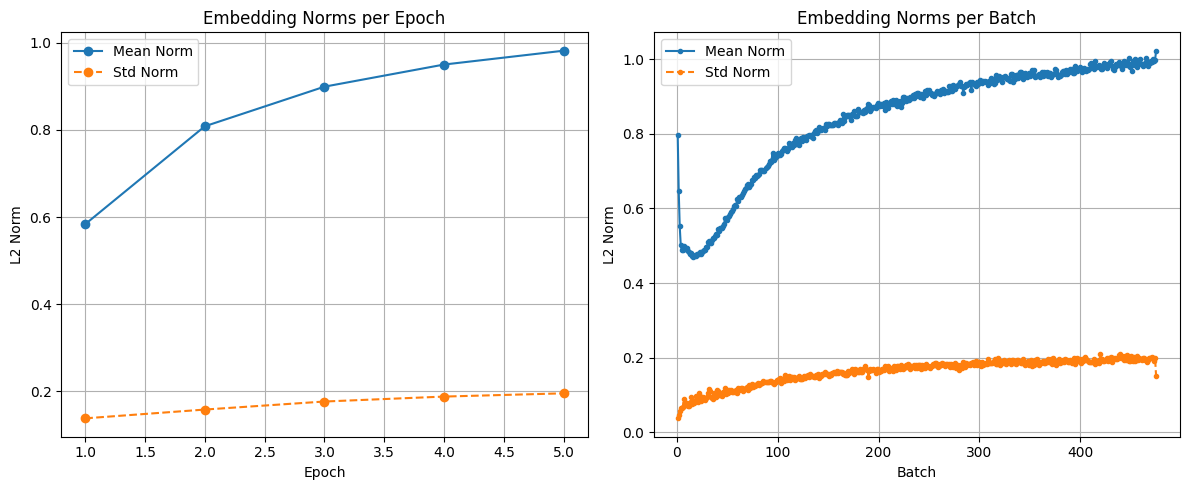

In [ ]:
###################
# MAIN TRAINING PIPELINE
###################

from BSARD.training_main import main_training_pipeline

# Execute main training pipeline
training_outputs , bundle_directory = main_training_pipeline(config)

print(bundle_directory)

# Relevant outputs saved within main_training_pipeline 